# Seasonal Precipitation Predictions with ACE2

## Setup

- define flags `RUN_DOWNLOADS`, `RUN_PREPROCESSING`, `RUN_FULL_EXPERIMENTS`
- define some constants + helper functions

In [36]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "test.yaml").exists():
    ROOT = Path("/home/seba/ace2")

RUN_DOWNLOADS = False
RUN_PREPROCESSING = False
RUN_FULL_EXPERIMENTS = False

SECONDS_PER_DAY = 86_400
MICROSECONDS_PER_DAY = SECONDS_PER_DAY * 1e6
FORECAST_STEPS = 360

WINDOW_STARTS = {
    "jfm": "2020-01-01T00:00:00",
    "fma": "2020-02-01T00:00:00",
    "mam": "2020-03-01T00:00:00",
    "amj": "2020-04-01T00:00:00",
    "mjj": "2020-05-01T00:00:00",
    "jja": "2020-06-01T00:00:00",
    "jas": "2020-07-01T00:00:00",
    "aso": "2020-08-01T00:00:00",
    "son": "2020-09-01T00:00:00",
    "ond": "2020-10-01T00:00:00",
}


def path(relative_path):
    return ROOT / relative_path


def run_cdo(*arguments, stdout=None):
    command = ["cdo", *(str(argument) for argument in arguments)]
    print("Running:", " ".join(command))
    return subprocess.run(command, check=True, stdout=stdout)


def write_ace_grid():
    grid_path = path("ace2_grid.txt")
    with grid_path.open("w") as grid_file:
        run_cdo("griddes", path("forcing_data/forcing_2020.nc"), stdout=grid_file)
    return grid_path


print(
    f"downloads={RUN_DOWNLOADS}, preprocessing={RUN_PREPROCESSING}, "
    f"full experiments={RUN_FULL_EXPERIMENTS}"
)
print(f"forecast windows={', '.join(WINDOW_STARTS)}")

downloads=False, preprocessing=False, full experiments=False
forecast windows=jfm, fma, mam, amj, mjj, jja, jas, aso, son, ond


## 2. Preparing for the Experiment

### Inspect ACE2 inputs

In [37]:
for name, filename in [
    ("Initial conditions", "initial_conditions/ic_2020.nc"),
    ("Forcing", "forcing_data/forcing_2020.nc"),
]:
    dataset = xr.open_dataset(path(filename))
    print(f"{name}: sizes={dict(dataset.sizes)}, variables={len(dataset.data_vars)}")

Initial conditions: sizes={'time': 12, 'latitude': 180, 'longitude': 360}, variables=38
Forcing: sizes={'time': 1464, 'latitude': 180, 'longitude': 360}, variables=25


### Download ECMWF data from CDS

In [38]:
if RUN_DOWNLOADS:
    import cdsapi

    request = {
        "originating_centre": "ecmwf",
        "system": "51",
        "year": ["2020"],
        "month": [start[5:7] for start in WINDOW_STARTS.values()],
        "day": ["01"],
        "leadtime_hour": [str(hour * 6) for hour in range(1, FORECAST_STEPS + 1)],
        "data_format": "netcdf",
    }
    client = cdsapi.Client()
    for variable, filename in [
        ("sea_ice_cover", "sea_ice.nc"),
        ("sea_surface_temperature", "sst.nc"),
    ]:
        client.retrieve(
            "seasonal-original-single-levels",
            {**request, "variable": [variable]},
        ).download(str(path(filename)))
        print(f"Saved {filename}")
else:
    print("Skipped ECMWF download from CDS (data should already be downloaded).")

Skipped ECMWF download from CDS (data should already be downloaded).


### Processing ECMWF Data

- takes averages of ensemble members
- LERPs to get sea ice predictions from daily to 6-hourly

In [39]:
sst_input = path("sst.nc")
ice_input = path("sea_ice.nc")

if RUN_PREPROCESSING:
    sst_dataset = xr.open_dataset(
        sst_input,
        chunks={"number": 1, "forecast_reference_time": 1, "forecast_period": 10},
    )
    ice_dataset = xr.open_dataset(
        ice_input,
        chunks={"number": 1, "forecast_reference_time": 1, "forecast_period": 5},
    )

    sst_mean = sst_dataset["sst"].mean("number", skipna=True)
    ice_mean_6h = (
        ice_dataset["siconc"].mean("number", skipna=True)
        .interp(forecast_period=sst_mean.forecast_period)
        .bfill("forecast_period")
        .clip(0.0, 1.0)
    )
    compression = {"zlib": True, "complevel": 4, "dtype": "float32"}
    for field, source, output_path in [
        (sst_mean, sst_dataset["sst"], path("sst_mean.nc")),
        (ice_mean_6h, ice_dataset["siconc"], path("sea_ice_mean_6h.nc")),
    ]:
        field.attrs = source.attrs
        field.to_dataset(name=field.name).to_netcdf(
            output_path, encoding={field.name: compression}
        )
        print(f"Saved {output_path.name}")
else:
    print("ECMWF preprocessing skipped (should already be done).")

ECMWF preprocessing skipped (should already be done).


#### Regrid ECMWF with CDO
- regrids ECMWF's lon/lat data to Gaussian using CDO
- inserts processed ECMWF data into artificial forcing data

In [40]:
template_path = path("forcing_data/forcing_2020.nc")
regridded_sst_path = path("sst_mean_ace_grid.nc")
regridded_ice_path = path("sea_ice_mean_6h_ace_grid.nc")

if RUN_PREPROCESSING:
    regridding_grid_path = write_ace_grid()
    for source_path, output_path in [
        (path("sst_mean.nc"), regridded_sst_path),
        (path("sea_ice_mean_6h.nc"), regridded_ice_path),
    ]:
        temporary_output = output_path.with_stem(f"{output_path.stem}.tmp")
        run_cdo(
            "-O", f"remapbil,{regridding_grid_path}", source_path, temporary_output
        )
        temporary_output.replace(output_path)

    template = xr.open_dataset(template_path)
    regridded_sst = xr.open_dataset(regridded_sst_path)
    regridded_ice = xr.open_dataset(regridded_ice_path)

    for name, dataset in [("sst", regridded_sst), ("ice", regridded_ice)]:
        latitude_difference = np.max(np.abs(dataset.latitude.values - template.latitude.values))
        assert np.allclose(dataset.latitude, template.latitude, rtol=0, atol=1e-10)
        print(f"{name} latitude mismatch: {latitude_difference:.2e}")

    available_start_times = set(
        np.datetime_as_string(regridded_sst.forecast_reference_time.values, unit="D")
    )
    missing_start_times = set(WINDOW_STARTS.values()) - available_start_times
    if missing_start_times:
        raise ValueError(
            "ECMWF data are missing forecast reference times: "
            f"{', '.join(sorted(missing_start_times))}"
        )

    for window, start_time in WINDOW_STARTS.items():
        start_time = np.datetime64(start_time)
        start_date = np.datetime_as_string(start_time, unit="D")
        sst = regridded_sst["sst"].sel(forecast_reference_time=start_time, drop=True)
        ice = regridded_ice["siconc"].sel(forecast_reference_time=start_time, drop=True).clip(0.0, 1.0)
        sst = sst.assign_coords(latitude=template.latitude, longitude=template.longitude)
        ice = ice.assign_coords(latitude=template.latitude, longitude=template.longitude)

        valid_times = start_time + sst.forecast_period.values
        sst = sst.rename(forecast_period="time").assign_coords(time=valid_times)
        ice = ice.rename(forecast_period="time").assign_coords(time=valid_times)
        output = template.sel(time=slice(start_time, valid_times[-1])).copy()
        output["sea_ice_fraction"].loc[{"time": valid_times}] = ice
        output["surface_temperature"].loc[{"time": valid_times}] = xr.where(
            sst.notnull(), sst, output["surface_temperature"].sel(time=valid_times)
        )

        if RUN_FULL_EXPERIMENTS:
            forcing_output = path(f"ecmwf_forcing/forcing_{start_date}.nc")
            forcing_output.parent.mkdir(exist_ok=True)
            encoding = {name: {"zlib": True, "complevel": 4} for name in output.data_vars}
            encoding["time"] = {
                key: template.time.encoding[key]
                for key in ("units", "calendar", "dtype")
                if key in template.time.encoding
            }
            temporary_output = forcing_output.with_stem(f"{forcing_output.stem}.tmp")
            output.to_netcdf(temporary_output, encoding=encoding)
            temporary_output.replace(forcing_output)
            print(f"Saved {window}: {forcing_output}")
    if not RUN_FULL_EXPERIMENTS:
        print("Skipped generating artificial forcing (should already be done).")
else:
    print("Skipped CDO regridding (should already be done).")

Skipped CDO regridding (should already be done).


### Inspect Generated Artificial Forcing Data

Compares the two key variables from ECMWF (SST and sea ice fraction) from the artificial forcing data and the real forcing data.

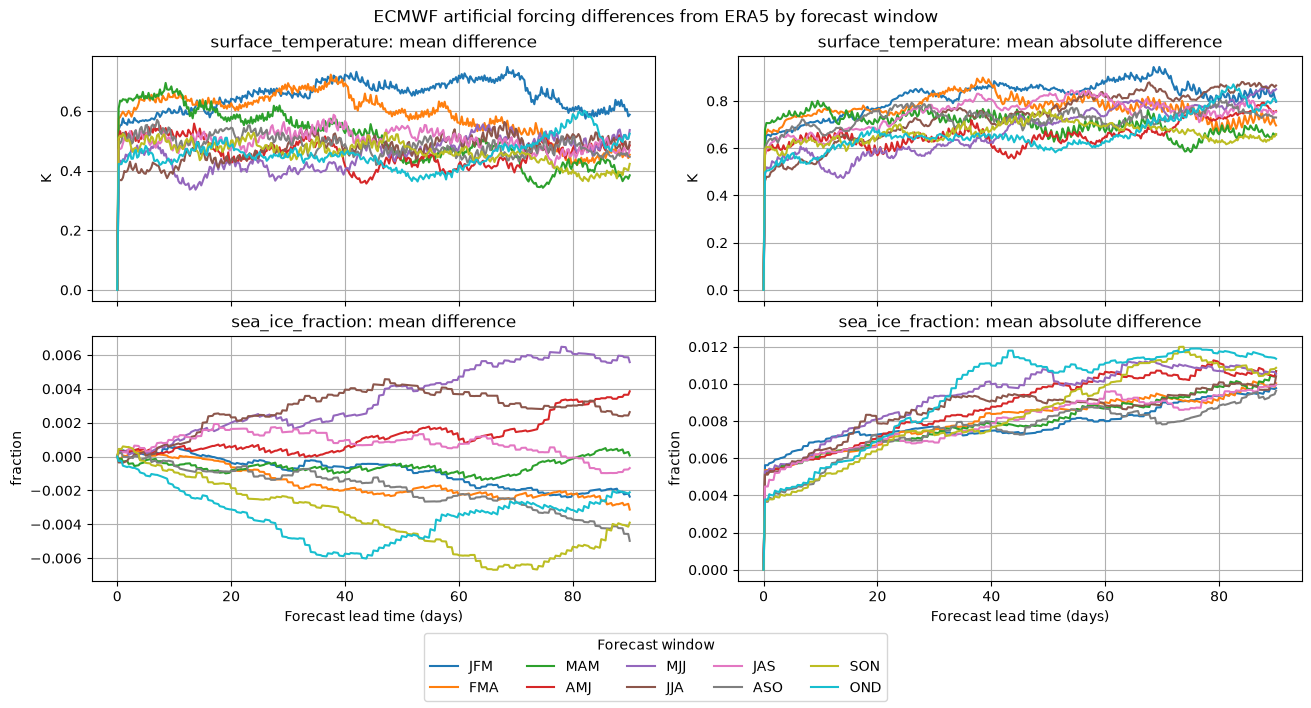

In [41]:
regular_forcing_path = path("forcing_data/forcing_2020.nc")
variables = [
    ("surface_temperature", "K"),
    ("sea_ice_fraction", "fraction"),
]

regular_forcing = xr.open_dataset(regular_forcing_path)
figure, axes = plt.subplots(2, 2, figsize=(13, 7), layout="constrained", sharex=True)

for row, (variable, unit) in enumerate(variables):
    mean_axis, absolute_axis = axes[row]
    for window, start_time in WINDOW_STARTS.items():
        start_date = np.datetime_as_string(np.datetime64(start_time), unit="D")
        artificial_forcing_path = path(f"ecmwf_forcing/forcing_{start_date}.nc")
        with xr.open_dataset(artificial_forcing_path) as artificial_forcing:
            observation = regular_forcing[variable].sel(time=artificial_forcing.time)
            difference = artificial_forcing[variable] - observation
            weights = np.cos(np.deg2rad(artificial_forcing.latitude))
            lead_days = (
                artificial_forcing.time - artificial_forcing.time.isel(time=0)
            ) / np.timedelta64(1, "D")
            mean_difference = difference.weighted(weights).mean(("latitude", "longitude")).load()
            mean_absolute_difference = abs(difference).weighted(weights).mean(
                ("latitude", "longitude")
            ).load()

        mean_axis.plot(lead_days, mean_difference, label=window.upper())
        absolute_axis.plot(lead_days, mean_absolute_difference, label=window.upper())

    mean_axis.set(title=f"{variable}: mean difference", ylabel=unit)
    absolute_axis.set(title=f"{variable}: mean absolute difference", ylabel=unit)
    mean_axis.grid()
    absolute_axis.grid()

axes[-1, 0].set_xlabel("Forecast lead time (days)")
axes[-1, 1].set_xlabel("Forecast lead time (days)")
handles, labels = axes[0, 0].get_legend_handles_labels()
figure.legend(handles, labels, title="Forecast window", loc="outside lower center", ncols=5)
figure.suptitle("ECMWF artificial forcing differences from ERA5 by forecast window")
figure.savefig(path("forcing_differences.png"), dpi=150)
plt.show()

# 3. Run Full Experiments

In [42]:
import gc
import tempfile

import yaml

experiment_configs = ["with_real_forcing.yaml", "with_artificial_forcing.yaml"]
required_output_files = (
    "annual_diagnostics.nc",
    "initial_condition.nc",
    "mean_diagnostics.nc",
    "monthly_mean_predictions.nc",
    "monthly_mean_target.nc",
    "power_spectrum_diagnostics.nc",
    "restart.nc",
    "time_mean_diagnostics.nc",
)

if RUN_FULL_EXPERIMENTS:
    for value in list(globals().values()):
        close = getattr(value, "close", None)
        if callable(close):
            close()
    gc.collect()

    for config_name in experiment_configs:
        config_path = path(config_name)
        base_config = yaml.safe_load(config_path.read_text())
        output_root = Path(base_config["experiment_dir"])

        for window, start_time in WINDOW_STARTS.items():
            experiment_dir = output_root / window
            if all((experiment_dir / filename).is_file() for filename in required_output_files):
                print(f"Skipped {config_name} {window}; outputs are already complete")
                continue

            config = yaml.safe_load(config_path.read_text())
            config["initial_condition"]["start_indices"]["times"] = [start_time]
            config["data_writer"]["save_prediction_files"] = False
            if config_name == "with_artificial_forcing.yaml":
                start_date = np.datetime_as_string(np.datetime64(start_time), unit="D")
                forcing_path = ROOT / "ecmwf_forcing" / f"forcing_{start_date}.nc"
                if not forcing_path.exists():
                    raise FileNotFoundError(f"Artificial forcing file not found: {forcing_path}")
                forcing_config = config["forcing_loader"]["dataset"]
                forcing_config["data_path"] = str(forcing_path.parent)
                forcing_config["file_pattern"] = forcing_path.name

            with tempfile.TemporaryDirectory(
                prefix=f"{experiment_dir.name}-", dir=experiment_dir.parent
            ) as staging_dir:
                staging_dir = Path(staging_dir)
                config["experiment_dir"] = str(staging_dir)
                staging_config = staging_dir / config_path.name
                staging_config.write_text(yaml.safe_dump(config, sort_keys=False))

                subprocess.run(
                    [
                        sys.executable,
                        "-m",
                        "fme.ace.validate_config",
                        str(staging_config),
                        "--config_type",
                        "inference",
                    ],
                    cwd=ROOT,
                    check=True,
                )
                subprocess.run(
                    [sys.executable, "-m", "fme.ace.inference", str(staging_config)],
                    cwd=ROOT,
                    check=True,
                )

                experiment_dir.mkdir(exist_ok=True)
                for output_path in staging_dir.glob("*.nc"):
                    output_path.replace(experiment_dir / output_path.name)
                print(f"Published {config_name} {window} outputs")
else:
    print("Skipped running full experiments (outputs should already be present).")

Skipped running full experiments (outputs should already be present).


### Inspect Precipitation Predictions of Experiments

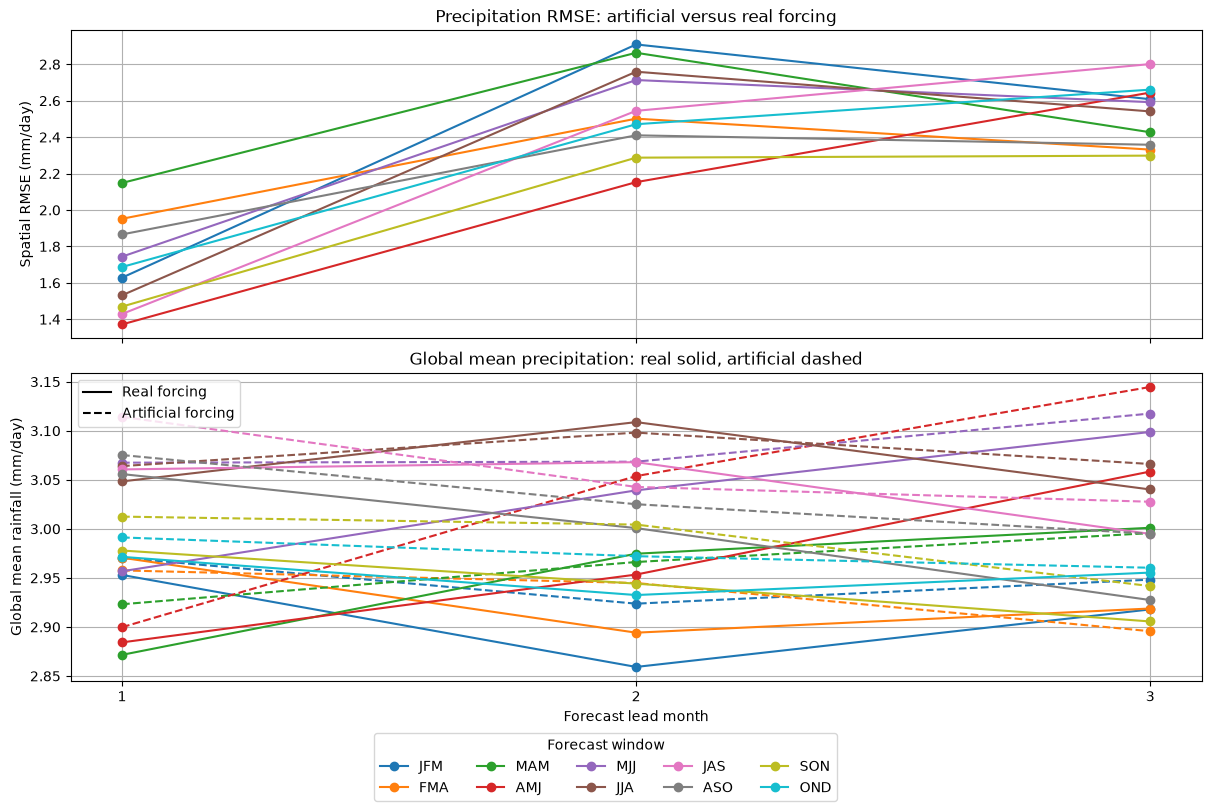

In [43]:
from matplotlib.lines import Line2D

prediction_paths = {
    window: (
        path(f"with_real_forcing/{window}/monthly_mean_predictions.nc"),
        path(f"with_artificial_forcing/{window}/monthly_mean_predictions.nc"),
    )
    for window in WINDOW_STARTS
}
missing_windows = [
    window
    for window, paths in prediction_paths.items()
    if not all(prediction_path.is_file() for prediction_path in paths)
]
if missing_windows:
    raise FileNotFoundError(
        "Missing monthly prediction outputs for: "
        f"{', '.join(window.upper() for window in missing_windows)}. "
        "Run the artificial-forcing inference cell first."
    )

precipitation_metrics = {}
for window, (real_predictions_path, artificial_predictions_path) in prediction_paths.items():
    with xr.open_dataset(real_predictions_path) as real_dataset, xr.open_dataset(
        artificial_predictions_path
    ) as artificial_dataset:
        # fma technically goes into fourth month becuase february is short.
        real = real_dataset["PRATEsfc"].squeeze("sample", drop=True).isel(time=slice(0, 3))
        artificial = artificial_dataset["PRATEsfc"].squeeze("sample", drop=True).isel(
            time=slice(0, 3)
        )
        real, artificial = xr.align(real, artificial, join="exact")
        weights = np.cos(np.deg2rad(real["lat"]))
        real_mm_day = real * SECONDS_PER_DAY
        artificial_mm_day = artificial * SECONDS_PER_DAY
        precipitation_metrics[window] = {
            "forcing_rmse": np.sqrt(
                ((artificial_mm_day - real_mm_day) ** 2).weighted(weights).mean(("lat", "lon"))
            ).load(),
            "real_mean": real_mm_day.weighted(weights).mean(("lat", "lon")).load(),
            "artificial_mean": artificial_mm_day.weighted(weights).mean(("lat", "lon")).load(),
        }

max_lead_month = max(metrics["forcing_rmse"].sizes["time"] for metrics in precipitation_metrics.values())
figure, axes = plt.subplots(2, 1, figsize=(12, 8), layout="constrained", sharex=True)
for window, metrics in precipitation_metrics.items():
    lead_months = metrics["forcing_rmse"]["time"].values + 1
    axes[0].plot(lead_months, metrics["forcing_rmse"], marker="o", label=window.upper())
    color = axes[0].lines[-1].get_color()
    axes[1].plot(lead_months, metrics["real_mean"], color=color, marker="o")
    axes[1].plot(lead_months, metrics["artificial_mean"], color=color, linestyle="--", marker="o")

axes[0].set(
    title="Precipitation RMSE: artificial versus real forcing",
    ylabel="Spatial RMSE (mm/day)",
)
axes[1].set(
    xlabel="Forecast lead month",
    ylabel="Global mean rainfall (mm/day)",
    title="Global mean precipitation: real solid, artificial dashed",
    xticks=np.arange(1, max_lead_month + 1),
)
axes[0].grid()
axes[1].grid()
window_handles, window_labels = axes[0].get_legend_handles_labels()
figure.legend(
    window_handles,
    window_labels,
    title="Forecast window",
    loc="outside lower center",
    ncols=5,
)
axes[1].legend(
    handles=[
        Line2D([0], [0], color="black", label="Real forcing"),
        Line2D([0], [0], color="black", linestyle="--", label="Artificial forcing"),
    ],
    loc="best",
)
figure.savefig(path("precipitation_difference.png"), dpi=150)
plt.show()

### Download ERA5 Data from CDS

In [44]:
era5_raw_path = path("era5_precip_1993_2020.nc")

if RUN_DOWNLOADS:
    import cdsapi

    request = {
        "product_type": ["monthly_averaged_reanalysis"],
        "variable": ["mean_total_precipitation_rate"],
        "year": [str(year) for year in range(1993, 2021)],
        "month": [f"{month:02d}" for month in range(1, 13)],
        "time": ["00:00"],
        "data_format": "netcdf",
        "download_format": "unarchived",
    }
    cdsapi.Client().retrieve(
        "reanalysis-era5-single-levels-monthly-means", request
    ).download(str(era5_raw_path))
    print(f"Saved {era5_raw_path}")
else:
    print("Skipped downloading ERA5 data from CDS (data should already be downloaded).")

Skipped downloading ERA5 data from CDS (data should already be downloaded).


### Process ERA5 precipitation

- convert mm/s to mm/day
- compute per month, per grid cell climatology

In [45]:
era5_mm_day_path = path("era5_monthly_precip_mm_day.nc")
era5_climatology_path = path("era5_monthly_climatology.nc")

if RUN_PREPROCESSING:
    precipitation = xr.open_dataset(era5_raw_path)["avg_tprate"] * SECONDS_PER_DAY
    precipitation.name, precipitation.attrs["units"] = "precipitation", "mm/day"
    precipitation.to_netcdf(era5_mm_day_path)

    climatology = precipitation.groupby("valid_time.month").mean("valid_time")
    climatology.name, climatology.attrs = "precipitation_climatology", precipitation.attrs
    climatology.to_netcdf(era5_climatology_path)
    print(f"Saved {era5_mm_day_path.name} and {era5_climatology_path.name}")
else:
    print("Skipped ERA5 preprocessing (should already be done).")

Skipped ERA5 preprocessing (should already be done).


### Regrid ERA5 for Comparison

In [46]:
era5_regridded_path = path("era5_monthly_precip_ace_grid.nc")
climatology_regridded_path = path("era5_monthly_climatology_ace_grid.nc")

if RUN_PREPROCESSING:
    ace_grid_path = write_ace_grid()
    for source_path, output_path in [
        (era5_mm_day_path, era5_regridded_path),
        (era5_climatology_path, climatology_regridded_path),
    ]:
        temporary_output = output_path.with_stem(f"{output_path.stem}.tmp")
        run_cdo(
            "-O", f"remapcon,{ace_grid_path}", source_path, temporary_output
        )
        temporary_output.replace(output_path)
else:
    print("Skipped ERA5 CDO regridding (outputs should already be present).")

Skipped ERA5 CDO regridding (outputs should already be present).


#### Evaluate ACE2 precipitation

- compare ACE2 predictions with ERA5 and climatology
- do some final sanity checks for stuff like errors in units/grid/predictions

In [47]:
PREDICTION_PATHS = {
    forcing: {
        window: path(f"with_{forcing}_forcing/{window}/monthly_mean_predictions.nc")
        for window in WINDOW_STARTS
    }
    for forcing in ("real", "artificial")
}
ERA5_PATH = path("era5_monthly_precip_ace_grid.nc")
CLIMATOLOGY_PATH = path("era5_monthly_climatology_ace_grid.nc")


def monthly_prediction(prediction_path):
    dataset = xr.open_dataset(prediction_path)
    raw = dataset["PRATEsfc"].isel(sample=0, time=slice(0, 3), drop=True).rename(
        {"lat": "latitude", "lon": "longitude"}
    )
    valid_times = dataset["valid_time"].isel(sample=0, time=slice(0, 3)).values
    return (raw * SECONDS_PER_DAY).rename(time="lead_month").assign_coords(
        lead_month=np.arange(raw.sizes["time"]),
        valid_time=("lead_month", valid_times),
    )


missing_predictions = [
    prediction_path
    for paths in PREDICTION_PATHS.values()
    for prediction_path in paths.values()
    if not prediction_path.exists()
]
if missing_predictions:
    raise FileNotFoundError(
        "Missing forecast outputs. Run the full experiment workflow first:\n"
        + "\n".join(str(prediction_path) for prediction_path in missing_predictions)
    )

prediction = xr.concat(
    [
        xr.concat(
            [
                monthly_prediction(prediction_path).expand_dims(window=[window])
                for window, prediction_path in window_paths.items()
            ],
            dim="window",
            join="exact",
            coords="all",
        ).expand_dims(forcing=[forcing])
        for forcing, window_paths in PREDICTION_PATHS.items()
    ],
    dim="forcing",
    join="exact",
    coords="all",
)
prediction.attrs["units"] = "mm/day"

era5_dataset = xr.open_dataset(ERA5_PATH)
climatology_dataset = xr.open_dataset(CLIMATOLOGY_PATH)
era5_2020 = era5_dataset["precipitation"].sel(
    valid_time=era5_dataset.valid_time.dt.year == 2020
)
era5_by_month = era5_2020.assign_coords(month=era5_2020.valid_time.dt.month).swap_dims(
    {"valid_time": "month"}
)
prediction_months = prediction.valid_time.dt.month
available_months = set(era5_by_month.month.values)
required_months = set(prediction_months.values.ravel())
missing_months = required_months - available_months
if missing_months:
    raise ValueError(f"ERA5 precipitation is missing months: {sorted(missing_months)}")

observation = era5_by_month.sel(month=prediction_months)
climatology = climatology_dataset["precipitation_climatology"].sel(month=prediction_months)
for name, field in [("observation", observation), ("climatology", climatology)]:
    assert field.sizes["latitude"] == prediction.sizes["latitude"], f"{name} latitude size mismatch"
    assert field.sizes["longitude"] == prediction.sizes["longitude"], f"{name} longitude size mismatch"

observation = observation.assign_coords(
    latitude=prediction.latitude,
    longitude=prediction.longitude,
    valid_time=prediction.valid_time,
)
climatology = climatology.assign_coords(
    latitude=prediction.latitude,
    longitude=prediction.longitude,
    valid_time=prediction.valid_time,
)
prediction, observation, climatology = xr.align(prediction, observation, climatology, join="exact")

for name, field in [("prediction", prediction), ("observation", observation), ("climatology", climatology)]:
    assert int(field.isnull().sum()) == 0, f"{name} contains NaNs :/"
    assert float(field.min()) >= -1e-5, f"{name} contains negative precipitation :/"

weights = np.cos(np.deg2rad(prediction.latitude))


def area_mean(field):
    return field.weighted(weights).mean(("latitude", "longitude"))


prediction_error = prediction - observation
climatology_error = climatology - observation
prediction_mse = area_mean(prediction_error**2)
climatology_mse = area_mean(climatology_error**2)
metrics = xr.Dataset(
    {
        "ACE2_mean_mm_day": area_mean(prediction),
        "ERA5_mean_mm_day": area_mean(observation),
        "climatology_mean_mm_day": area_mean(climatology),
        "ACE2_RMSE_mm_day": np.sqrt(prediction_mse),
        "climatology_RMSE_mm_day": np.sqrt(climatology_mse),
        "ACE2_bias_mm_day": area_mean(prediction_error),
        "MSE_skill_vs_climatology": 1.0 - prediction_mse / climatology_mse,
    }
)
summary_columns = [
    "ACE2_mean_mm_day",
    "ERA5_mean_mm_day",
    "climatology_mean_mm_day",
    "ACE2_RMSE_mm_day",
    "climatology_RMSE_mm_day",
    "ACE2_bias_mm_day",
    "MSE_skill_vs_climatology",
]
summary = metrics[summary_columns].mean("window").to_dataframe().reset_index()
display(summary.set_index(["forcing", "lead_month"])[summary_columns].round(3))

ACE2_mean_mm_day  ERA5_mean_mm_day  \
forcing    lead_month                                       
real       0                      2.975             2.958   
           1                      2.978             2.955   
           2                      2.982             2.949   
artificial 0                      3.008             2.958   
           1                      3.010             2.955   
           2                      3.009             2.949   

                       climatology_mean_mm_day  ACE2_RMSE_mm_day  \
forcing    lead_month                                              
real       0                             2.937             2.093   
           1                             2.938             2.446   
           2                             2.942             2.475   
artificial 0                             2.937             2.162   
           1                             2.938             2.529   
           2                             2.942             2.582   

                       climatology_RMSE_mm_day  ACE2_bias_mm_day  \
forcing    lead_month                                              
real       0                             1.651             0.017   
           1                             1.640             0.023   
           2                             1.624             0.033   
artificial 0                             1.651             0.050   
           1                             1.640             0.055   
           2                             1.624             0.061   

                       MSE_skill_vs_climatology  
forcing    lead_month                            
real       0                             -0.630  
           1                             -1.258  
           2                             -1.333  
artificial 0                             -0.738  
           1                             -1.412  
           2                             -1.541

### Spatial Analysis of ACE2's RMSE

For each grid cell, compute $\text{ACE2's prediction RMSE} - \text{Climatology RMSE}$, and plot this on a map.

We can see that climatology generally has lower RMSE than ACE2, but ACE2 is consistently better in certain regions.

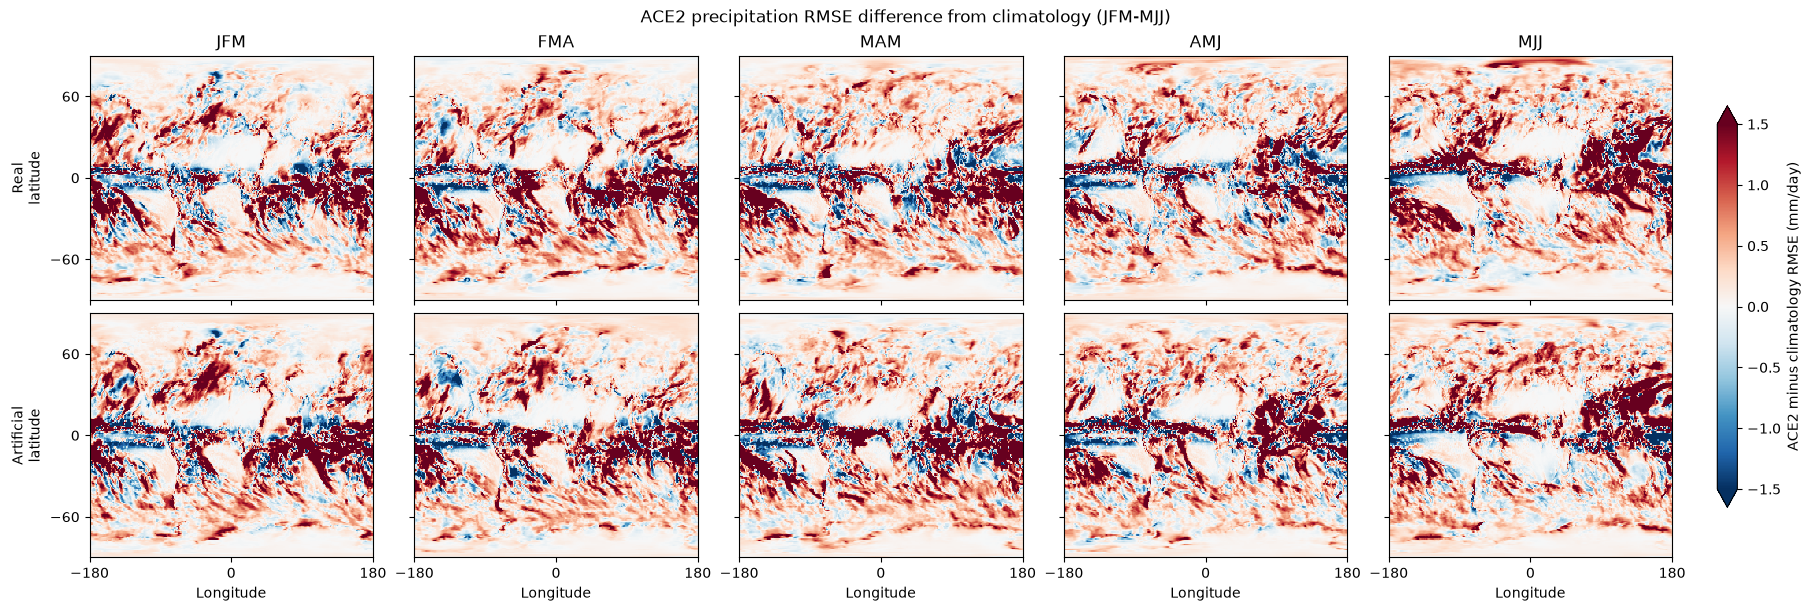

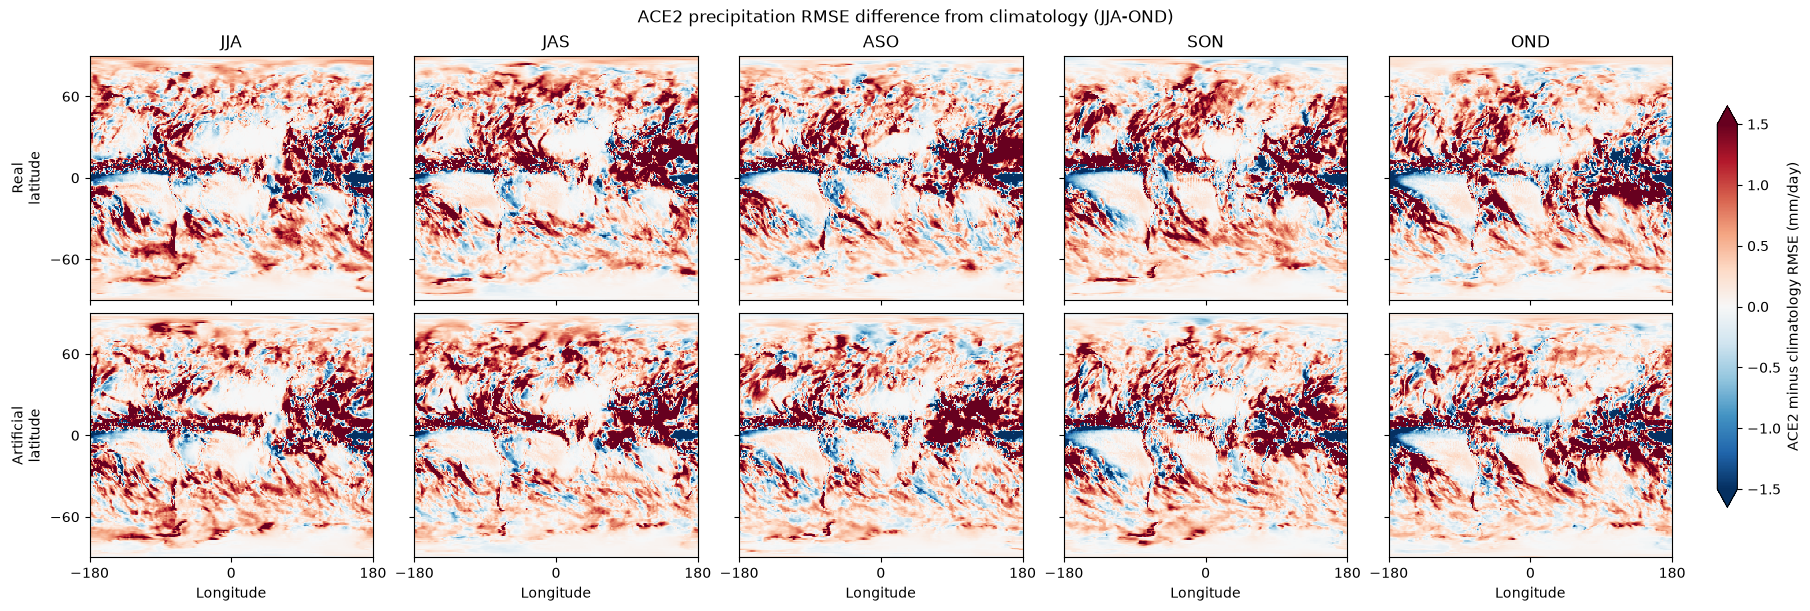

In [ ]:
spatial_prediction_rmse = np.sqrt(((prediction - observation) ** 2).mean("lead_month"))
spatial_climatology_rmse = np.sqrt(((climatology - observation) ** 2).mean("lead_month"))
spatial_rmse_difference = spatial_prediction_rmse - spatial_climatology_rmse
rmse_limit = 1.5

forcings = list(PREDICTION_PATHS)
windows = list(WINDOW_STARTS)
for batch_start in range(0, len(windows), 5):
    window_batch = windows[batch_start : batch_start + 5]
    figure, axes = plt.subplots(
        len(forcings),
        len(window_batch),
        figsize=(18, 6),
        constrained_layout=True,
        sharex=True,
        sharey=True,
    )

    for row, forcing in enumerate(forcings):
        for column, window in enumerate(window_batch):
            axis = axes[row, column]
            difference = spatial_rmse_difference.sel(forcing=forcing, window=window)
            difference = difference.assign_coords(
                longitude=(difference.longitude + 180) % 360 - 180
            ).sortby("longitude")
            image = axis.pcolormesh(
                difference.longitude,
                difference.latitude,
                difference,
                cmap="RdBu_r",
                vmin=-rmse_limit,
                vmax=rmse_limit,
                shading="auto",
            )
            axis.set(xlim=(-180, 180), ylim=(-90, 90))
            axis.set_xticks((-180, 0, 180))
            axis.set_yticks((-60, 0, 60))
            axis.tick_params(labelbottom=row == len(forcings) - 1, labelleft=column == 0)
            if row == 0:
                axis.set_title(window.upper())
            if column == 0:
                axis.set_ylabel(f"{forcing.capitalize()}\nlatitude")
            if row == len(forcings) - 1:
                axis.set_xlabel("Longitude")

    colorbar = figure.colorbar(image, ax=axes, pad=0.02, shrink=0.8, extend="both")
    colorbar.set_label("ACE2 minus climatology RMSE (mm/day)")
    figure.suptitle(
        f"ACE2 precipitation RMSE difference from climatology ({window_batch[0].upper()}-{window_batch[-1].upper()})"
    )
    plt.show()

Compute $1 - \frac{\text{ACE2's prediction MSE }}{\text{Climatology MSE}}$ and plot this on a map. The idea is that this metric gives a good (unit-independent) way of quantifying the performance relative to climatology.

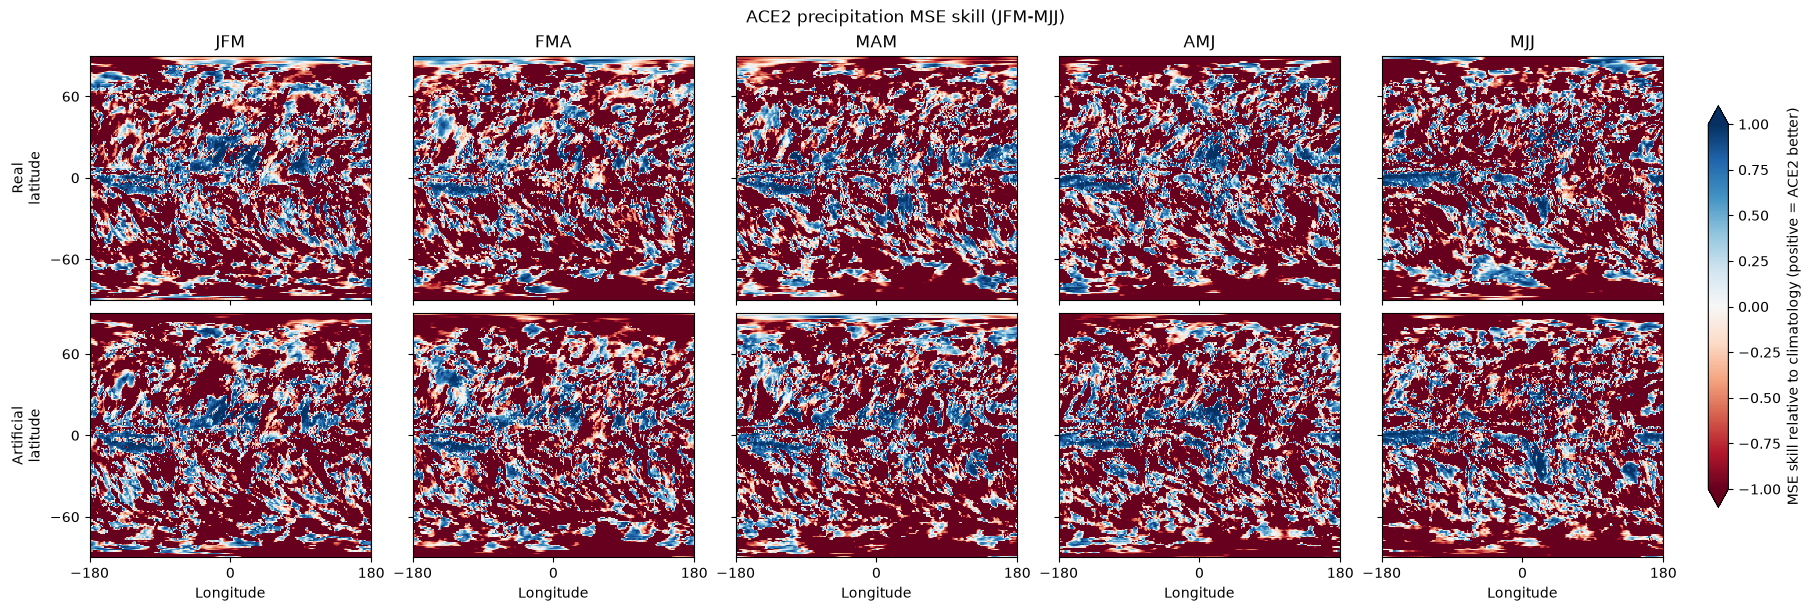

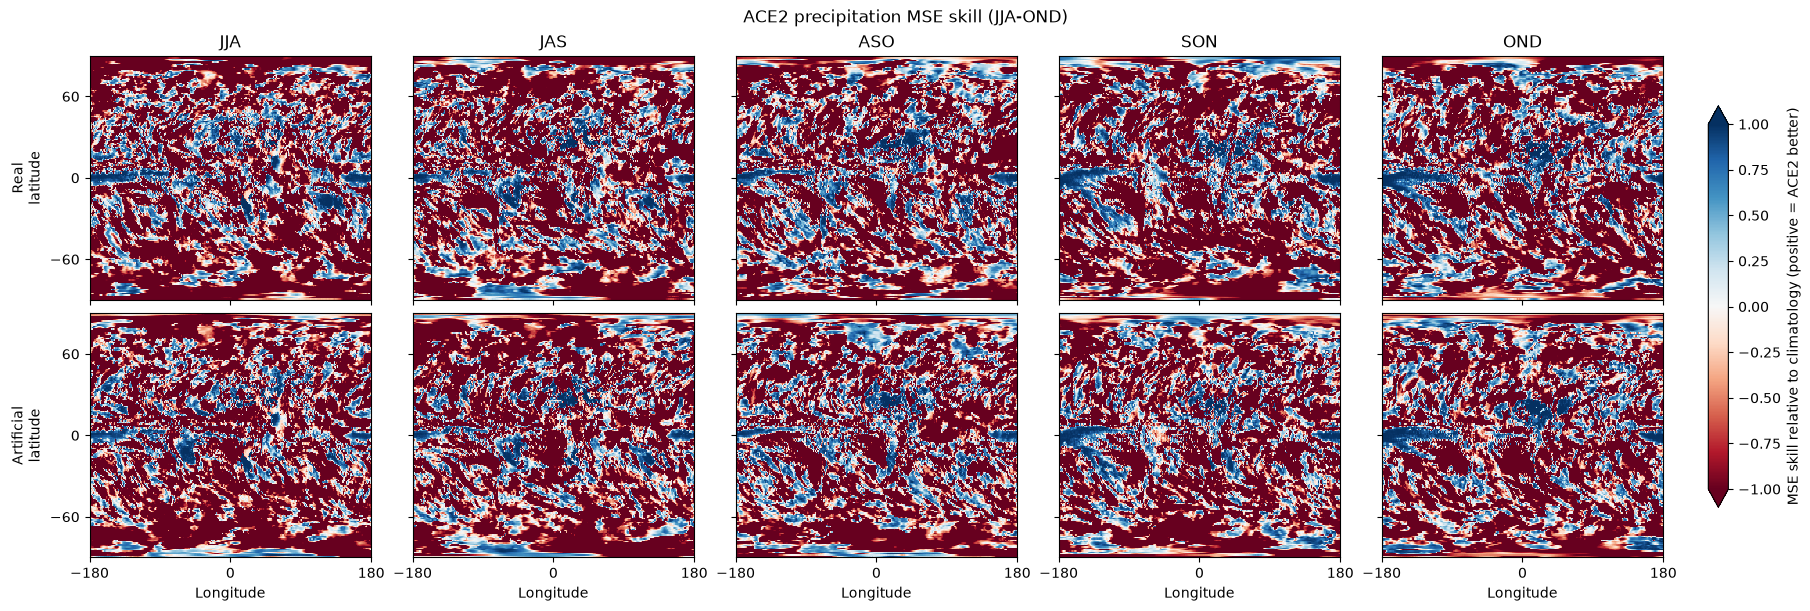

In [49]:
spatial_prediction_mse = ((prediction - observation) ** 2).mean("lead_month")
spatial_climatology_mse = ((climatology - observation) ** 2).mean("lead_month")
spatial_mse_skill = 1.0 - spatial_prediction_mse / spatial_climatology_mse
spatial_mse_skill = spatial_mse_skill.where(spatial_climatology_mse > 0)

skill_limit = 1.0
forcings = list(PREDICTION_PATHS)
windows = list(WINDOW_STARTS)
for batch_start in range(0, len(windows), 5):
    window_batch = windows[batch_start : batch_start + 5]
    figure, axes = plt.subplots(
        len(forcings),
        len(window_batch),
        figsize=(18, 6),
        constrained_layout=True,
        sharex=True,
        sharey=True,
    )

    for row, forcing in enumerate(forcings):
        for column, window in enumerate(window_batch):
            axis = axes[row, column]
            skill = spatial_mse_skill.sel(forcing=forcing, window=window)
            skill = skill.assign_coords(
                longitude=(skill.longitude + 180) % 360 - 180
            ).sortby("longitude")
            image = axis.pcolormesh(
                skill.longitude,
                skill.latitude,
                skill,
                cmap="RdBu",
                vmin=-skill_limit,
                vmax=skill_limit,
                shading="auto",
            )
            axis.set(xlim=(-180, 180), ylim=(-90, 90))
            axis.set_xticks((-180, 0, 180))
            axis.set_yticks((-60, 0, 60))
            axis.tick_params(labelbottom=row == len(forcings) - 1, labelleft=column == 0)
            if row == 0:
                axis.set_title(window.upper())
            if column == 0:
                axis.set_ylabel(f"{forcing.capitalize()}\nlatitude")
            if row == len(forcings) - 1:
                axis.set_xlabel("Longitude")

    colorbar = figure.colorbar(image, ax=axes, pad=0.02, shrink=0.8, extend="both")
    colorbar.set_label("MSE skill relative to climatology (positive = ACE2 better)")
    figure.suptitle(
        f"ACE2 precipitation MSE skill ({window_batch[0].upper()}-{window_batch[-1].upper()})"
    )
    plt.show()

### Analysis of ACE2 RMSE Relative to Precipitation Values

Scatter plot of error against precipitation, for ACE2's predictions and climatology. Each point on the scatter plot is one grid cell, averaged over the precitions windows.

As might be expected for both ACE2's predictions and climatology, the RMSE grows (super-linearly) with precipitation, with very high correlation.

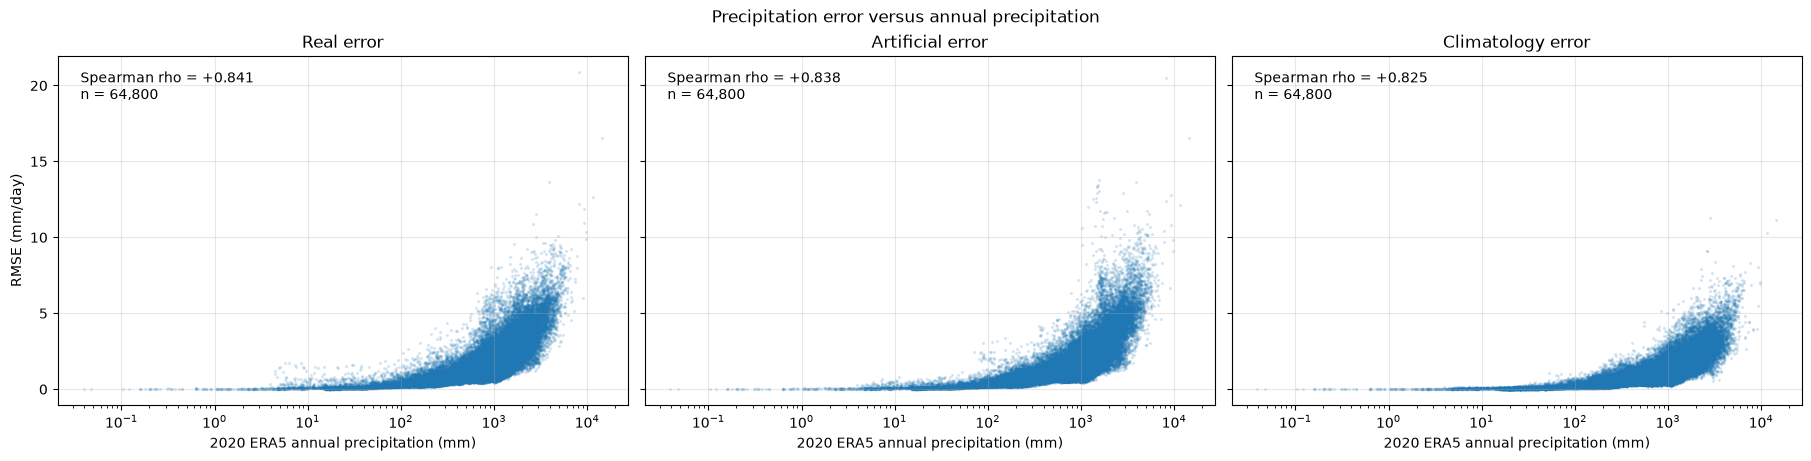

,spearman_rho,spearman_p_value,grid_cell_count
comparison,,,
real,0.8409,0.0,64800
artificial,0.8385,0.0,64800
climatology,0.8251,0.0,64800


In [ ]:
from scipy.stats import spearmanr

# annual 2020 ERA5 precipitation amount in mm, using each month's calendar length.
month_days = era5_by_month.valid_time.dt.days_in_month
annual_precipitation = (era5_by_month * month_days).sum("month")
annual_precipitation = annual_precipitation.assign_coords(
    latitude=prediction.latitude,
    longitude=prediction.longitude,
 )
annual_precipitation.name = "annual_precipitation_mm"

# local RMSE across all three-month forecast windows and lead months.
spatial_rmse = np.sqrt(((prediction - observation) ** 2).mean(("window", "lead_month")))
spatial_rmse.name = "ACE2_RMSE_mm_day"
spatial_climatology_rmse = np.sqrt(
    ((climatology - observation) ** 2).mean(("forcing", "window", "lead_month"))
)
spatial_climatology_rmse.name = "climatology_RMSE_mm_day"

error_fields = {
    "real": spatial_rmse.sel(forcing="real"),
    "artificial": spatial_rmse.sel(forcing="artificial"),
    "climatology": spatial_climatology_rmse,
}
spearman_rho = []
spearman_p_value = []
grid_cell_count = []
figure, axes = plt.subplots(
    1,
    len(error_fields),
    figsize=(18, 4.5),
    layout="constrained",
    sharey=True,
 )

for axis, (label, error) in zip(np.atleast_1d(axes), error_fields.items()):
    valid = np.isfinite(annual_precipitation) & np.isfinite(error) & (annual_precipitation > 0)
    precipitation_values = annual_precipitation.where(valid).values.ravel()
    error_values = error.where(valid).values.ravel()
    valid_values = np.isfinite(precipitation_values) & np.isfinite(error_values)

    rho, p_value = spearmanr(
        precipitation_values[valid_values],
        error_values[valid_values],
    )
    spearman_rho.append(rho)
    spearman_p_value.append(p_value)
    grid_cell_count.append(valid_values.sum())

    axis.scatter(
        precipitation_values[valid_values],
        error_values[valid_values],
        s=2,
        alpha=0.12,
        color="tab:blue",
        rasterized=True,
    )
    axis.set(
        xscale="log",
        xlabel="2020 ERA5 annual precipitation (mm)",
        title=f"{label.capitalize()} error",
    )
    axis.grid(alpha=0.3)
    axis.text(
        0.04,
        0.96,
        f"Spearman rho = {rho:+.3f}\nn = {valid_values.sum():,}",
        transform=axis.transAxes,
        va="top",
    )

axes[0].set_ylabel("RMSE (mm/day)")
figure.suptitle("Precipitation error versus annual precipitation")
plt.show()

spearman_results = xr.Dataset(
    {
        "spearman_rho": ("comparison", spearman_rho),
        "spearman_p_value": ("comparison", spearman_p_value),
        "grid_cell_count": ("comparison", grid_cell_count),
    },
    coords={"comparison": list(error_fields)},
)
display(spearman_results.to_dataframe().round(4))

Scatter plot of (ACE2 RMSE) - (climatology RMSE) against precipitation. Each point on the scatter plot is one grid cell, averaged over the precitions windows.

We can see that ACE2's RMSE is higher for all ranges of precipitation values, though it does sometimes have lower RMSE at high precipitation values.

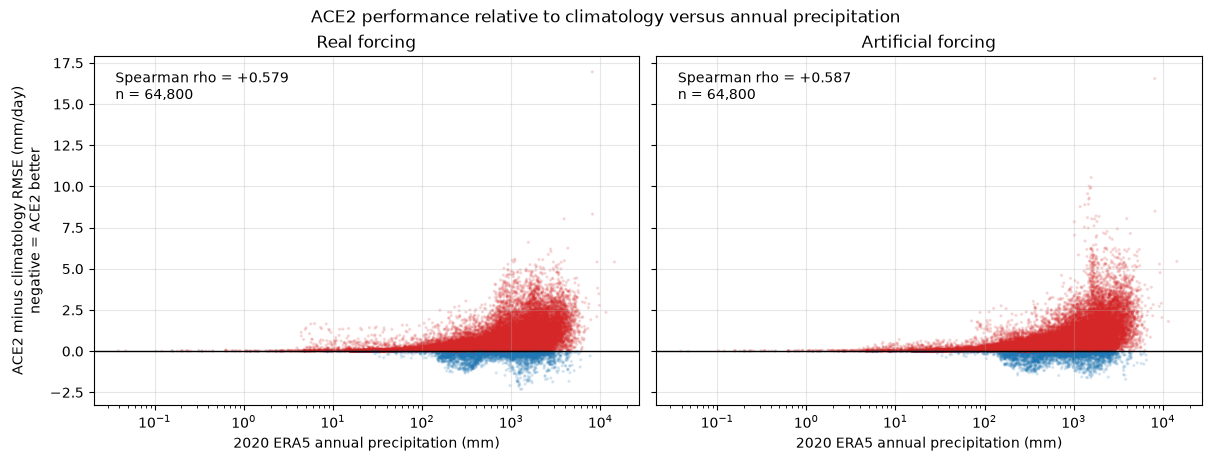

,spearman_rho,spearman_p_value,grid_cell_count
forcing,,,
real,0.5793,0.0,64800
artificial,0.5867,0.0,64800


In [ ]:
from scipy.stats import spearmanr

# annual 2020 ERA5 precipitation amount in mm, using each month's calendar length.
month_days = era5_by_month.valid_time.dt.days_in_month
annual_precipitation = (era5_by_month * month_days).sum("month").assign_coords(
    latitude=prediction.latitude,
    longitude=prediction.longitude,
 )

spatial_ace2_rmse = np.sqrt(
    ((prediction - observation) ** 2).mean(("window", "lead_month"))
)
spatial_climatology_rmse = np.sqrt(
    ((climatology - observation) ** 2).mean(("forcing", "window", "lead_month"))
)
relative_rmse = spatial_ace2_rmse - spatial_climatology_rmse

forcings = list(PREDICTION_PATHS)
relative_spearman_rho = []
relative_spearman_p_value = []
grid_cell_count = []
figure, axes = plt.subplots(1, len(forcings), figsize=(12, 4.5), layout="constrained", sharey=True)

for axis, forcing in zip(np.atleast_1d(axes), forcings):
    rmse_difference = relative_rmse.sel(forcing=forcing)
    valid = np.isfinite(annual_precipitation) & np.isfinite(rmse_difference) & (annual_precipitation > 0)
    precipitation_values = annual_precipitation.where(valid).values.ravel()
    difference_values = rmse_difference.where(valid).values.ravel()
    valid_values = np.isfinite(precipitation_values) & np.isfinite(difference_values)

    rho, p_value = spearmanr(
        precipitation_values[valid_values],
        difference_values[valid_values],
    )
    relative_spearman_rho.append(rho)
    relative_spearman_p_value.append(p_value)
    grid_cell_count.append(valid_values.sum())

    point_colors = np.where(difference_values[valid_values] > 0, "tab:red", "tab:blue")
    axis.scatter(
        precipitation_values[valid_values],
        difference_values[valid_values],
        s=2,
        alpha=0.12,
        c=point_colors,
        rasterized=True,
    )
    axis.axhline(0, color="black", linewidth=1)
    axis.set(
        xscale="log",
        xlabel="2020 ERA5 annual precipitation (mm)",
        title=f"{forcing.capitalize()} forcing",
    )
    axis.grid(alpha=0.3)
    axis.text(
        0.04,
        0.96,
        f"Spearman rho = {rho:+.3f}\nn = {valid_values.sum():,}",
        transform=axis.transAxes,
        va="top",
    )

axes[0].set_ylabel("ACE2 minus climatology RMSE (mm/day)\nnegative = ACE2 better")
figure.suptitle("ACE2 performance relative to climatology versus annual precipitation")
plt.show()

relative_spearman_results = xr.Dataset(
    {
        "spearman_rho": ("forcing", relative_spearman_rho),
        "spearman_p_value": ("forcing", relative_spearman_p_value),
        "grid_cell_count": ("forcing", grid_cell_count),
    },
    coords={"forcing": forcings},
)
display(relative_spearman_results.to_dataframe().round(4))

### ACC Analysis

For each lead month, compute the ACC over all grid cells.

This means that ACE2's anomaly predictions tend to have the same sign as the observed anomalies (though the magnitude of the predicted anomalies might be wrong).

In [ ]:
ace2_anomaly = prediction - climatology
observed_anomaly = observation - climatology


def spatial_acc(forecast_anomaly, target_anomaly):
    covariance = (forecast_anomaly * target_anomaly).weighted(weights).mean(
        ("latitude", "longitude")
    )
    forecast_std = np.sqrt(
        (forecast_anomaly**2).weighted(weights).mean(("latitude", "longitude"))
    )
    target_std = np.sqrt(
        (target_anomaly**2).weighted(weights).mean(("latitude", "longitude"))
    )
    return covariance / (forecast_std * target_std)


acc = spatial_acc(ace2_anomaly, observed_anomaly)
acc.name = "ACC"
assert bool(np.isfinite(acc).all()), "ACC contains non-finite values"

acc_by_lead = xr.Dataset(
    {
        "ACC_mean": acc.mean("window"),
        "ACC_window_std": acc.std("window"),
    }
).assign_coords(lead_month=acc.lead_month + 1)

display(acc_by_lead.to_dataframe().round(3))

ACC_mean  ACC_window_std
forcing    lead_month                          
real       1              0.345           0.094
           2              0.119           0.086
           3              0.100           0.092
artificial 1              0.349           0.082
           2              0.121           0.066
           3              0.105           0.092

To understand why it has such bad RMSE given that it does a good job of predicting the sign of the anomaly, we investigate the magnitude of its anomaly predictions. We find that it generally predicts an anomly about 20-30% too high. This suggests that perhaps we can improve the quality of the predictions by keeping the sign but scaling down the anomaly prediction by some amount.

That is, we use a formula like

$$ y = c + \alpha * (p - c)$$

for some constant alpha (where $c$ and $p$ are the climatology and prediction, respectively).

In [53]:
# Pooled area-weighted anomaly RMS across all forecast windows.
rms_weights = np.cos(np.deg2rad(prediction.latitude))
ace2_anomaly_rms = np.sqrt(
    (ace2_anomaly**2).weighted(rms_weights).mean(("latitude", "longitude")).mean("window")
)
observed_anomaly_rms = np.sqrt(
    (observed_anomaly**2).weighted(rms_weights).mean(("latitude", "longitude")).mean("window")
)
anomaly_rms_ratio = ace2_anomaly_rms / observed_anomaly_rms
assert bool(np.isfinite(anomaly_rms_ratio).all()), "Anomaly RMS ratio contains non-finite values"

anomaly_rms_summary = xr.Dataset(
    {
        "ACE2_anomaly_RMS_mm_day": ace2_anomaly_rms,
        "ERA5_anomaly_RMS_mm_day": observed_anomaly_rms,
        "ACE2_to_ERA5_anomaly_RMS_ratio": anomaly_rms_ratio,
    }
).assign_coords(lead_month=ace2_anomaly_rms.lead_month + 1)

print("Ratio > 1: ACE2 anomalies are stronger than ERA5; ratio < 1: weaker.")
display(anomaly_rms_summary.to_dataframe().round(3))

Ratio > 1: ACE2 anomalies are stronger than ERA5; ratio < 1: weaker.


ACE2_anomaly_RMS_mm_day  ERA5_anomaly_RMS_mm_day  \
forcing    lead_month                                                     
real       1                             1.991                    1.656   
           2                             2.021                    1.644   
           3                             2.039                    1.626   
artificial 1                             2.095                    1.656   
           2                             2.137                    1.644   
           3                             2.191                    1.626   

                       ACE2_to_ERA5_anomaly_RMS_ratio  
forcing    lead_month                                  
real       1                                    1.202  
           2                                    1.229  
           3                                    1.254  
artificial 1                                    1.265  
           2                                    1.300  
           3                                    1.347

To further investigate the same thing, let's investigate how the ACC varies with the absolute precipiation of the grid cell.

Specifically, over grid cells with (low/medium/high), what does ACE2's climatology tend to be?

Annual precipitation split into 10 equal-count buckets


lead 1  lead 2  lead 3
forcing    annual precipitation                        
Real       <= 113 mm              0.281   0.111   0.003
           113-254 mm             0.435   0.202   0.185
           254-361 mm             0.476   0.253   0.188
           361-554 mm             0.396   0.171   0.109
           554-750 mm             0.315   0.093   0.019
           750-933 mm             0.282   0.074   0.018
           933-1107 mm            0.280   0.060   0.050
           1107-1337 mm           0.312   0.118   0.064
           1337-1829 mm           0.323   0.093   0.059
           > 1829 mm              0.364   0.134   0.141
Artificial <= 113 mm              0.252   0.009   0.133
           113-254 mm             0.370   0.197   0.204
           254-361 mm             0.446   0.220   0.177
           361-554 mm             0.367   0.162   0.079
           554-750 mm             0.330   0.113   0.056
           750-933 mm             0.310   0.064   0.048
           933-1107 mm            0.300   0.072   0.034
           1107-1337 mm           0.346   0.081   0.096
           1337-1829 mm           0.321   0.040   0.015
           > 1829 mm              0.364   0.165   0.150

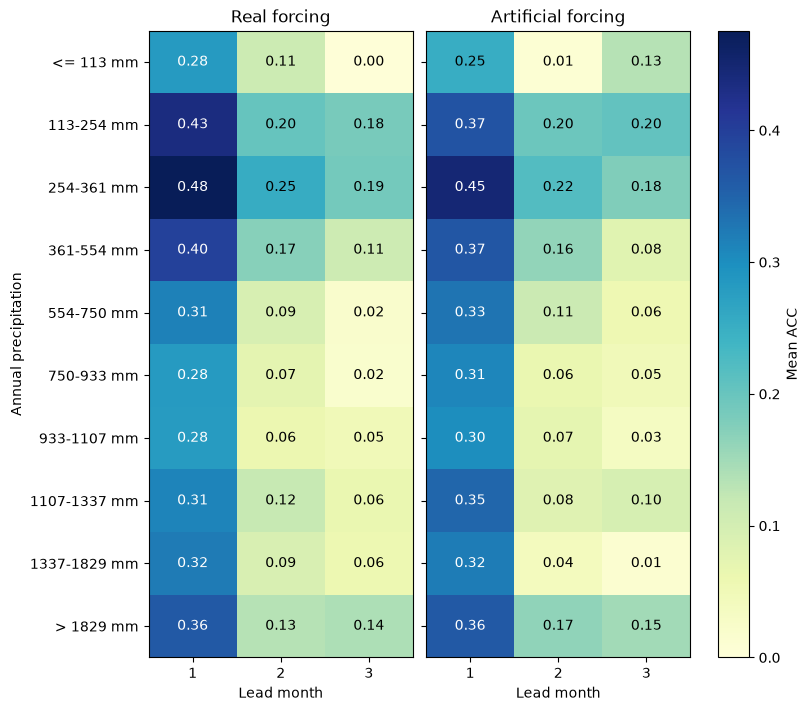

In [54]:
import pandas as pd

N_PRECIPITATION_BUCKETS = 10

month_days = era5_by_month.valid_time.dt.days_in_month
annual_precipitation = (era5_by_month * month_days).sum("month").assign_coords(
    latitude=prediction.latitude,
    longitude=prediction.longitude,
)
bucket_edges = annual_precipitation.quantile(
    np.linspace(0, 1, N_PRECIPITATION_BUCKETS + 1)
).values

precipitation_buckets = {}
for bucket_index in range(N_PRECIPITATION_BUCKETS):
    lower_edge = bucket_edges[bucket_index]
    upper_edge = bucket_edges[bucket_index + 1]
    if bucket_index == 0:
        label = f"<= {upper_edge:.0f} mm"
        mask = annual_precipitation <= upper_edge
    elif bucket_index == N_PRECIPITATION_BUCKETS - 1:
        label = f"> {lower_edge:.0f} mm"
        mask = annual_precipitation > lower_edge
    else:
        label = f"{lower_edge:.0f}-{upper_edge:.0f} mm"
        mask = (annual_precipitation > lower_edge) & (annual_precipitation <= upper_edge)
    precipitation_buckets[label] = mask

acc_by_bucket = xr.concat(
    [
        spatial_acc(ace2_anomaly.where(mask), observed_anomaly.where(mask))
        for mask in precipitation_buckets.values()
    ],
    dim=xr.IndexVariable("precipitation_bucket", list(precipitation_buckets)),
)
assert bool(np.isfinite(acc_by_bucket).all()), "Bucket ACC contains non-finite values"

acc_by_bucket_mean = acc_by_bucket.mean("window")
table_rows = []
for forcing in PREDICTION_PATHS:
    for bucket in precipitation_buckets:
        row = {"forcing": forcing.capitalize(), "annual precipitation": bucket}
        for lead_month in acc_by_bucket.lead_month.values:
            row[f"lead {lead_month + 1}"] = float(
                acc_by_bucket_mean.sel(
                    forcing=forcing, precipitation_bucket=bucket, lead_month=lead_month
                )
            )
        table_rows.append(row)

print(f"Annual precipitation split into {N_PRECIPITATION_BUCKETS} equal-count buckets")
display(
    pd.DataFrame(table_rows)
.set_index(["forcing", "annual precipitation"])
.round(3)
)

figure, axes = plt.subplots(
    1,
    len(PREDICTION_PATHS),
    figsize=(8, max(4, 0.55 * N_PRECIPITATION_BUCKETS + 1.5)),
    sharey=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)
heatmap_max = float(acc_by_bucket_mean.max())
for axis, forcing in zip(axes, PREDICTION_PATHS):
    values = acc_by_bucket_mean.sel(forcing=forcing).transpose(
        "precipitation_bucket", "lead_month"
)
    image = axis.imshow(values, cmap="YlGnBu", vmin=0, vmax=heatmap_max, aspect="auto")
    axis.set_title(f"{forcing.capitalize()} forcing")
    axis.set_xticks(range(values.sizes["lead_month"]), values.lead_month.values + 1)
    axis.set_xlabel("Lead month")
    axis.set_yticks(range(values.sizes["precipitation_bucket"]), values.precipitation_bucket.values)
    for row_index, bucket in enumerate(values.precipitation_bucket.values):
        for column_index, lead_month in enumerate(values.lead_month.values):
            value = float(values.sel(precipitation_bucket=bucket, lead_month=lead_month))
            text_color = "white" if value > heatmap_max * 0.55 else "black"
            axis.text(
                column_index,
                row_index,
                f"{value:.2f}",
                ha="center",
                va="center",
                color=text_color,
            )
axes[0].set_ylabel("Annual precipitation")
figure.colorbar(image, ax=axes, label="Mean ACC")
plt.show()

A similar idea, but instead investigating how our ACC varies based on our prediction (rather than the true value).

For example: over all cells with low precipitation, what ACC does ACE2's predictions have?

ACE2 predictions split into 10 equal-count buckets


lead 1  lead 2  lead 3
forcing    ACE2 precipitation percentile                        
Real       lowest 10%                      0.498   0.304   0.356
           10-20%                          0.510   0.397   0.505
           20-30%                          0.583   0.360   0.319
           30-40%                          0.487   0.271   0.219
           40-50%                          0.429   0.172   0.106
           50-60%                          0.376   0.111   0.070
           60-70%                          0.323   0.071   0.081
           70-80%                          0.262   0.059   0.024
           80-90%                          0.260   0.043   0.051
           highest 10%                     0.348   0.125   0.097
Artificial lowest 10%                      0.555   0.511   0.351
           10-20%                          0.555   0.566   0.437
           20-30%                          0.606   0.452   0.260
           30-40%                          0.575   0.312   0.170
           40-50%                          0.483   0.190   0.100
           50-60%                          0.396   0.110   0.076
           60-70%                          0.306   0.069   0.036
           70-80%                          0.260   0.004   0.009
           80-90%                          0.250  -0.008  -0.003
           highest 10%                     0.349   0.127   0.125

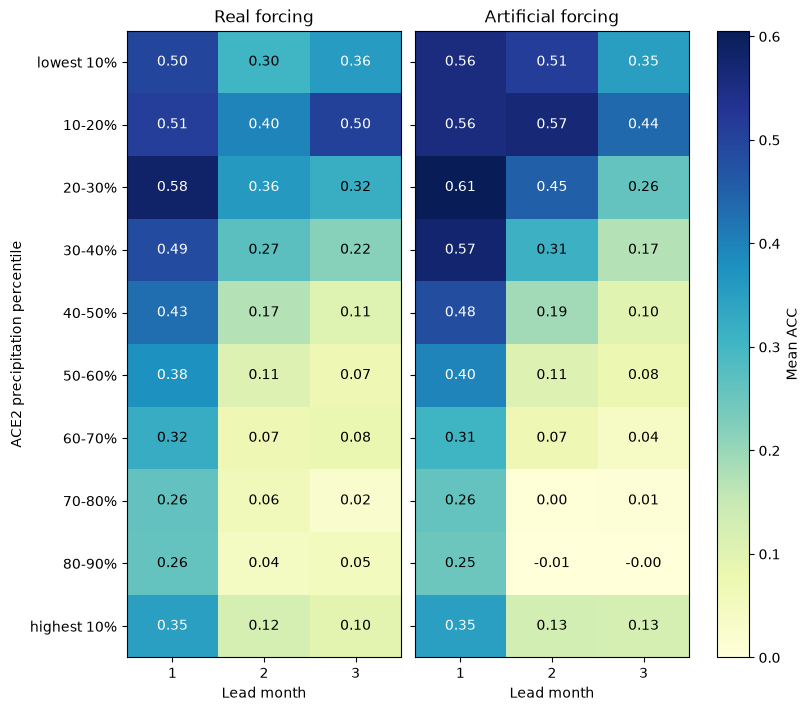

In [ ]:
# classify each forecast grid point by its ACE2 precipitation percentile.
prediction_quantiles = prediction.quantile(
    np.linspace(0, 1, N_PRECIPITATION_BUCKETS + 1),
    dim=("window", "lead_month", "latitude", "longitude"),
)

prediction_buckets = {}
for bucket_index in range(N_PRECIPITATION_BUCKETS):
    lower_quantile = prediction_quantiles.isel(quantile=bucket_index, drop=True)
    upper_quantile = prediction_quantiles.isel(quantile=bucket_index + 1, drop=True)
    lower_percentile = 100 * bucket_index / N_PRECIPITATION_BUCKETS
    upper_percentile = 100 * (bucket_index + 1) / N_PRECIPITATION_BUCKETS
    if bucket_index == 0:
        label = f"lowest {upper_percentile:.0f}%"
        mask = prediction <= upper_quantile
    elif bucket_index == N_PRECIPITATION_BUCKETS - 1:
        label = f"highest {100 - lower_percentile:.0f}%"
        mask = prediction > lower_quantile
    else:
        label = f"{lower_percentile:.0f}-{upper_percentile:.0f}%"
        mask = (prediction > lower_quantile) & (prediction <= upper_quantile)
    prediction_buckets[label] = mask

bucket_membership = sum(prediction_buckets.values())
assert bool((bucket_membership == 1).all()), "Prediction buckets must be disjoint and complete"

acc_by_prediction_bucket = xr.concat(
    [
        spatial_acc(ace2_anomaly.where(mask), observed_anomaly.where(mask))
        for mask in prediction_buckets.values()
    ],
    dim=xr.IndexVariable("prediction_bucket", list(prediction_buckets)),
)
assert bool(np.isfinite(acc_by_prediction_bucket).all()), (
    "Prediction-bucket ACC contains non-finite values"
 )

acc_by_prediction_bucket_mean = acc_by_prediction_bucket.mean("window")
prediction_table_rows = []
for forcing in PREDICTION_PATHS:
    for bucket in prediction_buckets:
        row = {"forcing": forcing.capitalize(), "ACE2 precipitation percentile": bucket}
        for lead_month in acc_by_prediction_bucket.lead_month.values:
            row[f"lead {lead_month + 1}"] = float(
                acc_by_prediction_bucket_mean.sel(
                    forcing=forcing, prediction_bucket=bucket, lead_month=lead_month
                )
            )
        prediction_table_rows.append(row)

print(f"ACE2 predictions split into {N_PRECIPITATION_BUCKETS} equal-count buckets")
display(
    pd.DataFrame(prediction_table_rows)
.set_index(["forcing", "ACE2 precipitation percentile"])
.round(3)
)

figure, axes = plt.subplots(
    1,
    len(PREDICTION_PATHS),
    figsize=(8, max(4, 0.55 * N_PRECIPITATION_BUCKETS + 1.5)),
    sharey=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)
heatmap_max = float(acc_by_prediction_bucket_mean.max())
for axis, forcing in zip(axes, PREDICTION_PATHS):
    values = acc_by_prediction_bucket_mean.sel(forcing=forcing).transpose(
        "prediction_bucket", "lead_month"
)
    image = axis.imshow(values, cmap="YlGnBu", vmin=0, vmax=heatmap_max, aspect="auto")
    axis.set_title(f"{forcing.capitalize()} forcing")
    axis.set_xticks(range(values.sizes["lead_month"]), values.lead_month.values + 1)
    axis.set_xlabel("Lead month")
    axis.set_yticks(range(values.sizes["prediction_bucket"]), values.prediction_bucket.values)
    for row_index, bucket in enumerate(values.prediction_bucket.values):
        for column_index, lead_month in enumerate(values.lead_month.values):
            value = float(values.sel(prediction_bucket=bucket, lead_month=lead_month))
            text_color = "white" if value > heatmap_max * 0.55 else "black"
            axis.text(
                column_index,
                row_index,
                f"{value:.2f}",
                ha="center",
                va="center",
                color=text_color,
            )
axes[0].set_ylabel("ACE2 precipitation percentile")
figure.colorbar(image, ax=axes, label="Mean ACC")
plt.show()

### Trying the Damping Idea

Trying out the idea from above of weighting down the anomaly prediction, which seems to be too high in general.

Formally, let $c$ be climatology, $p$ the ACE2 prediction, and $y$ the ERA5 observation. The damped forecast is

$$
c + \alpha(p-c).
$$

Define $e_c=c-y$ and $a=p-c$. Its error is $e_c+\alpha a$, so the pooled, area-weighted MSE is a quadratic in $\alpha$:

$$
\mathrm{MSE}(\alpha)
= \langle(e_c+\alpha a)^2\rangle
= A + 2B\alpha + D\alpha^2,
$$

where $A=\langle e_c^2\rangle$, $B=\langle e_c a\rangle$, and $D=\langle a^2\rangle$. Here $\langle\cdot\rangle$ is the cosine-latitude-weighted spatial mean, averaged across forecast windows.

This is minimised for $\alpha=-B/D$. 

The optimal alpha in $[0, 1]$ is just

$$
\alpha_{\mathrm{best}}=\operatorname{clip}\left(-\frac{B}{D},0,1\right).
$$

The corresponding RMSE is $\sqrt{\mathrm{MSE}(\alpha_{\mathrm{best}})}$.

The result is that for each lead month, there is a choice of alpha for which the damped predictions beat climatology for RMSE, but this alpha (and the margin by which we beat climatology) is quite small after lead month 1.

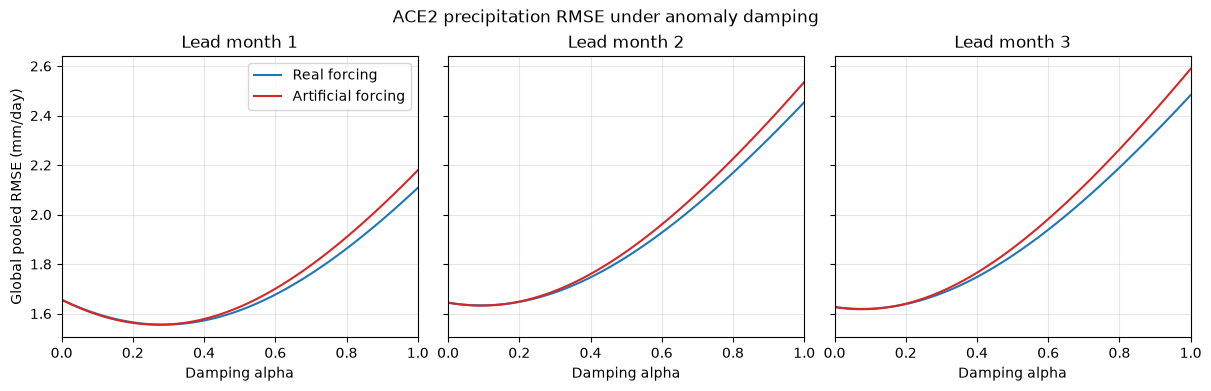

best_alpha  best_RMSE_mm_day  climatology_RMSE_mm_day  \
forcing    lead_month                                                          
real       1                0.286             1.555                    1.656   
           2                0.094             1.633                    1.644   
           3                0.077             1.619                    1.626   
artificial 1                0.272             1.555                    1.656   
           2                0.092             1.632                    1.644   
           3                0.077             1.618                    1.626   

                       ACE2_RMSE_mm_day  
forcing    lead_month                    
real       1                      2.108  
           2                      2.454  
           3                      2.483  
artificial 1                      2.179  
           2                      2.535  
           3                      2.589

In [ ]:
alphas = xr.DataArray(np.linspace(0.0, 1.0, 101), dims="alpha", name="alpha")

# just so that I can run this cell independently of other ones (weights are the same)
damping_weights = np.cos(np.deg2rad(prediction.latitude))


def damping_area_mean(field):
    return field.weighted(damping_weights).mean(("latitude", "longitude"))


climatology_error = climatology - observation
ace2_anomaly = prediction - climatology
baseline_mse = damping_area_mean(climatology_error**2).mean("window")
cross_term = damping_area_mean(climatology_error * ace2_anomaly).mean("window")
anomaly_mse = damping_area_mean(ace2_anomaly**2).mean("window")
damped_mse = baseline_mse + 2 * alphas * cross_term + alphas**2 * anomaly_mse
damped_rmse = np.sqrt(damped_mse)

figure, axes = plt.subplots(
    1,
    damped_rmse.sizes["lead_month"],
    figsize=(12, 3.8),
    layout="constrained",
    sharey=True,
)
for axis, lead_month in zip(np.atleast_1d(axes), damped_rmse.lead_month.values):
    for forcing, color in (("real", "tab:blue"), ("artificial", "tab:red")):
        curve = damped_rmse.sel(forcing=forcing, lead_month=lead_month)
        axis.plot(alphas, curve, color=color, label=f"{forcing.capitalize()} forcing")
    axis.set(
        xlabel="Damping alpha",
        title=f"Lead month {lead_month + 1}",
        xlim=(0, 1),
        xticks=np.arange(0, 1.01, 0.2),
    )
    axis.grid(alpha=0.3)

axes[0].set_ylabel("Global pooled RMSE (mm/day)")
axes[0].legend()
figure.suptitle("ACE2 precipitation RMSE under anomaly damping")
plt.show()

best_alpha = (-cross_term / anomaly_mse).clip(min=0, max=1)
best_rmse = np.sqrt(baseline_mse + 2 * best_alpha * cross_term + best_alpha**2 * anomaly_mse)
damping_summary = xr.Dataset(
    {
        "best_alpha": best_alpha,
        "best_RMSE_mm_day": best_rmse,
        "climatology_RMSE_mm_day": np.sqrt(baseline_mse),
        "ACE2_RMSE_mm_day": np.sqrt(baseline_mse + 2 * cross_term + anomaly_mse),
    }
).assign_coords(lead_month=damped_rmse.lead_month + 1)
display(damping_summary.to_dataframe().round(3))